''' 1. TouchandGo '''

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('touchandgo-clf.csv')
df['acc'] = df['acc'] * 100

/tmp/ipykernel_327523/878871008.py:60: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


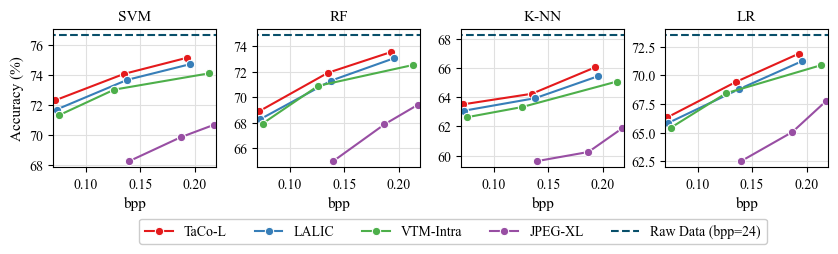

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.color'] = '#000000'
plt.rcParams['ytick.color'] = '#000000'

classifiers = ['SVM', 'RF', 'K-NN', 'LR']

hue_order = ['TaCo-L', 'LALIC', 'VTM-Intra', 'JPEG-XL']
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8))
plt.subplots_adjust(wspace=0.25)
for i, clf in enumerate(classifiers):
    ax = axes[i]
    legend = True if i == 3 else False
    sns.lineplot(
        df[(df['classifier']==clf) & (df['compressor']!='Raw Data')], x='bpp', y='acc', hue='compressor', hue_order=hue_order, marker='o', markersize=6, palette='Set1', ax=ax, legend=legend
    )
    
    # Raw Data acc
    raw_acc = df[(df['classifier']==clf) & (df['compressor']=='Raw Data')]['acc'].iloc[0]
    xmin, xmax = ax.get_xlim()
    ax.hlines(raw_acc, xmin, xmax, colors='#084f6a', linestyles='--', label=f'Raw Data (bpp=24)', linewidth=1.5)
    
    ax.set_title(clf)
    ax.set_xlim(0.07, 0.22)
    ax.grid(True, zorder=0, color='#e0e0e0')
    if i == 0:
        ax.set_ylabel("Accuracy (%)")
    else:
        ax.set_ylabel("")
    ax.set_xlabel("bpp")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

handles, labels = axes[3].get_legend_handles_labels()
axes[3].legend(
    handles, labels,
    title='',
    loc='upper center',
    bbox_to_anchor=(-1.3, -0.35),
    ncol=9,
    columnspacing=2,
    handleheight=0.45,
    # handlelength=1.5,
    # handletextpad=0.25,
    # labelspacing=0.3,
    frameon=True,
    framealpha=1.0,
    borderaxespad=0.2
)


plt.tight_layout()
plt.savefig('touchandgo-clf.pdf', dpi=400, bbox_inches='tight')
